In [ ]:
# Imports
import qutip as qt
import matplotlib.pyplot as plt
import numpy as np

from scipy.optimize import curve_fit # not used this time, but we'll want it later


Hello Qutip World

In [2]:
print("Qutip version:",qt.__version__) # Should be on 5.X.X

Qutip version: 5.0.4


# Defining states and operators

In [114]:
# --- 1. Qubits (2-level systems) ---
# Define a qubit basis state |0> (Ground state)
psi_qubit = qt.basis(2, 0) 

# Define Pauli Spin operators
sx = qt.sigmax()
sy = qt.sigmay()
sz = qt.sigmaz()

sigma_plus = qt.basis(2,1) * qt.basis(2,0).dag()  # |1><0|
sigma_minus = sigma_plus.dag()  # |0><1|

print(sigma_plus)
print(qt.sigmap()) # NOTE: qt.sigmap() has the opposite matrix representation!!  When in doubt, construct manually as above

# --- 2. Harmonic Oscillators (N-level systems) ---
N = 10  # Size of the Hilbert space
# Define a coherent state with alpha = 2.0
psi_osc = qt.coherent(N, 2.0) 

# Define Ladder Operators (annihilation and creation)
a = qt.destroy(N)
a_dag = a.dag() # .dag() is the Hermitian conjugate

print("Qubit State |0>:\n", psi_qubit)
print("\nPauli X Operator:\n", sx)
print("\nCommutator [a, a_dagger]:\n", a * a_dag - a_dag * a) # Should be Identity

Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=Dense, isherm=False
Qobj data =
[[0. 0.]
 [1. 0.]]
Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=CSR, isherm=False
Qobj data =
[[0. 1.]
 [0. 0.]]
Qubit State |0>:
 Quantum object: dims=[[2], [1]], shape=(2, 1), type='ket', dtype=Dense
Qobj data =
[[1.]
 [0.]]

Pauli X Operator:
 Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=CSR, isherm=True
Qobj data =
[[0. 1.]
 [1. 0.]]

Commutator [a, a_dagger]:
 Quantum object: dims=[[10], [10]], shape=(10, 10), type='oper', dtype=Dia, isherm=True
Qobj data =
[[ 1.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  1.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  1.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  1.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  1.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  1.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  1.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  1.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  1.  0.]
 [ 0. 

In [186]:
# let's compute probability of measing |1> for some random state

random_state = (1/np.sqrt(5)) * qt.basis(2,0) + (2/np.sqrt(5)) * qt.basis(2,1)

P_0 = qt.expect(qt.basis(2,0) * qt.basis(2,0).dag(), random_state)
P_1 = qt.expect(qt.basis(2,1) * qt.basis(2,1).dag(), random_state)

print(f"\nProbability of measuring |0>: {P_0}")
print(f"Probability of measuring |1>: {P_1}")


Probability of measuring |0>: 0.19999999999999998
Probability of measuring |1>: 0.7999999999999999


# Working with Hamiltonians

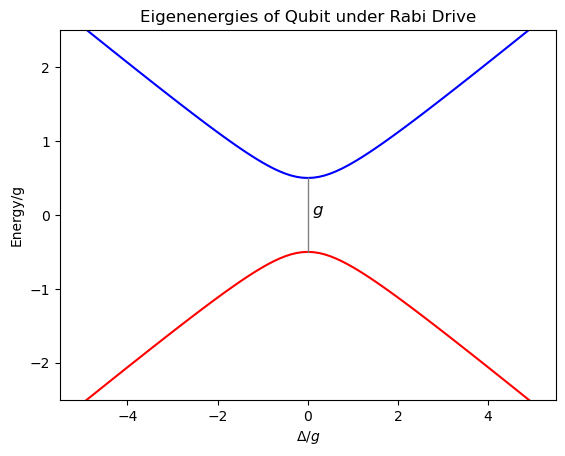

In [120]:
Delta_over_g_vals = np.linspace(-5,5,81)

eigenenergies_list = []
for Delta_over_g in Delta_over_g_vals:

    H = (0.5 * Delta_over_g * qt.sigmaz() + 0.5 * qt.sigmax())

    eigenenergies_list.append(H.eigenenergies())

eigenenergies_list = np.array(eigenenergies_list)
plt.figure()
plt.plot(Delta_over_g_vals, np.array(eigenenergies_list[:,0]),'r')
plt.plot(Delta_over_g_vals, np.array(eigenenergies_list[:,1]),'b')

plt.xlabel(r'$\Delta/g$')
plt.ylabel('Energy/g')
plt.ylim(-2.5,2.5)
# plt.grid()
plt.title('Eigenenergies of Qubit under Rabi Drive')

plt.text(0.1, 0, r'$g$', fontsize=12, color='black')
plt.axvline(x=0,ymin=2/5,ymax=3/5, color='gray', linestyle='-', linewidth=1)

In [126]:
H = (0.4328 * qt.sigmaz() + 0.9599 * qt.sigmax() - 1.29 * qt.sigmay())

eigenenergies,eigenstates = H.eigenstates()

print(f"We have eigenenergies: {eigenenergies}")
print(f"We have corresponding eigenstates:")
print(eigenstates)

We have eigenenergies: [-1.66517983  1.66517983]
We have corresponding eigenstates:
[Quantum object: dims=[[2], [1]], shape=(2, 1), type='ket', dtype=Dense
 Qobj data =
 [[ 0.60831247+0.j        ]
  [-0.47381427+0.63675425j]]
 Quantum object: dims=[[2], [1]], shape=(2, 1), type='ket', dtype=Dense
 Qobj data =
 [[-0.79369763+0.j        ]
  [-0.36314475+0.48802659j]]                                           ]


# Unitary time evolution with `sesolve`

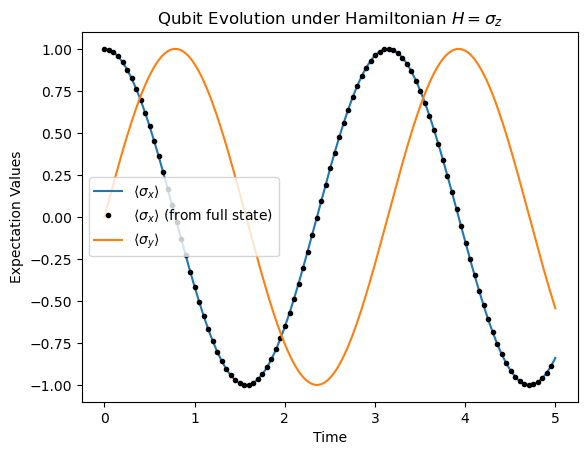

In [138]:
psi0 = (qt.basis(2,0) + qt.basis(2,1)).unit()  # define initial state
tlist = np.linspace(0, 5, 1000)  # define time values to solve over


H = (1 * qt.sigmaz() ) # define Hamiltonian to evolve under

exp_ops = [qt.sigmax(), qt.sigmay()]  # define operators to evaluate expectation values for
result = qt.sesolve(H, psi0, tlist, exp_ops)  # solve the Schrodinger equation

# alternatively, we could give no exp_ops and instead get the entire state psi(t)
result_full = qt.sesolve(H, psi0, tlist)  # solve the Schrodinger equation

my_X_expect_from_full = [qt.expect(qt.sigmax(), psi_t) for psi_t in result_full.states]


plt.figure()
plt.plot(tlist, result.expect[0], label=r'$\langle \sigma_x \rangle$')
plt.plot(tlist[::10], my_X_expect_from_full[::10], 'k.', label=r'$\langle \sigma_x \rangle$ (from full state)')
plt.plot(tlist, result.expect[1], label=r'$\langle \sigma_y \rangle$')
plt.xlabel('Time')
plt.ylabel(r'Expectation Values')
plt.title('Qubit Evolution under Hamiltonian $H = \sigma_z$')
plt.legend()
plt.show()



In [137]:
# If a 2D plot vs time is desired, we can run the above code in a for loop over a range of Hamiltonian parameters
# and store the expectation values in a 2D array for plotting with imshow or pcolormesh. This is left as an exercise for the student.

# Simulating decoherence with `mesolve`

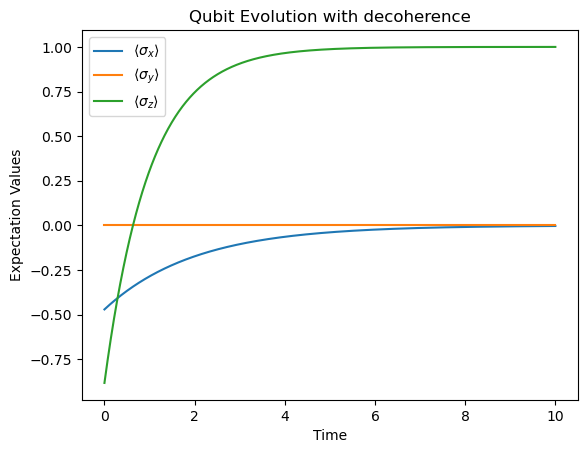

In [180]:
# Simulating a T1 decay process

psi0 = (1*qt.basis(2,0) - 4*qt.basis(2,1)).unit()  # we again define an initial state
rho0 = psi0 * psi0.dag()  # if our initial state is not pure, we can give it as a density matrix
tlist = np.linspace(0, 10, 1000)  # define time values to solve over (same as before)

H = (1 * qt.identity(2) ) # define Hamiltonian to evolve under

# Next, to simulate non-unitary evolution (i.e., including decoherence processes), we need to define collapse operators.

T1 = 1.0  # decay time
gamma1 = 1 / T1  # decay rate
c_op_decay = [np.sqrt(gamma1) * qt.basis(2,0) * qt.basis(2,1).dag()]  # collapse operator for T1 decay

Tphi = 1.0  # dephasing time
gamma_phi = 1 / Tphi  # dephasing rate
c_ops_dephasing = [np.sqrt(gamma_phi) * qt.sigmaz()]  # collapse operator for dephasing


exp_ops = [qt.sigmax(), qt.sigmay(), qt.sigmaz()]  # define operators to evaluate expectation values for
result = qt.mesolve(H, rho0, tlist, c_op_decay, exp_ops)  # solve the master equation

# can similarly get the full density matrix at each time if desired
result_full = qt.mesolve(H, rho0, tlist, c_op_decay)  # solve the master equation

# To compute the purity, we could use qt.metrics.purity on each density matrix


plt.figure()
plt.plot(tlist, result.expect[0], label=r'$\langle \sigma_x \rangle$')
plt.plot(tlist, result.expect[1], label=r'$\langle \sigma_y \rangle$')
plt.plot(tlist, result.expect[2], label=r'$\langle \sigma_z \rangle$')
plt.xlabel('Time')
plt.ylabel(r'Expectation Values')
plt.title('Qubit Evolution with decoherence')
plt.legend()
plt.show()

# Plotting on the Bloch Sphere

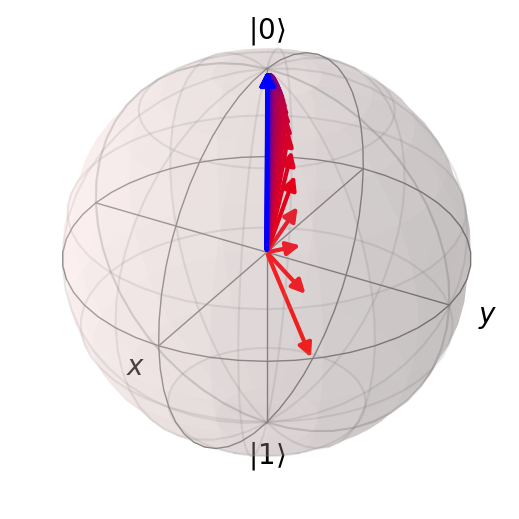

In [183]:
import matplotlib.colors as mcolors 

b = qt.Bloch()

states_to_plot = result_full.states[::25] # select every 25th state for plotting, don't want to overcrowd the Bloch sphere
num_states = len(states_to_plot)

# 1. Create a list of HEX color strings
colors = []
for i in range(num_states):
    blue_intensity = i / (num_states - 1)
    red_intensity = 1 - blue_intensity
    # Convert RGB tuple to Hex string (e.g., '#FF0000')
    colors.append(mcolors.to_hex((red_intensity, 0, blue_intensity)))

# 2. Add the states
b.add_states(states_to_plot, kind='vector')

# 3. Assign the colors explicitly to the Bloch object, for some reason passing it directly doesn't work
b.vector_color = colors 

b.show()